# 📊 14. Grayscale NTSC Testing CNN

Notebook ini mengevaluasi kinerja murni model CNN pada dataset testing CIFAR-10 (10.000 sampel).
Menampilkan metrik komprehensif: Loss, Accuracy, Precision, Recall, F1-Score, Classification Report, dan Confusion Matrix.


In [1]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import json
import numpy as np
import tensorflow as tf

# Aktifkan GPU memory growth agar hemat VRAM & mencegah error 'DNN library is not found'
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass


ARTIFACT_DIR = 'cifar10_artifacts/grayscale_ntsc'
model_path = os.path.join(ARTIFACT_DIR, 'custom_cnn_cifar10_final.keras')
if not os.path.exists(model_path):
    model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')

print(f"Memuat model CNN dari: {model_path}")
cnn_model = tf.keras.models.load_model(model_path)
print(f"Model berhasil dimuat: {cnn_model.name}")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def load_cifar10_test_data():
    _, (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    X_test = X_test.astype('float32') / 255.0
    y_test = y_test.flatten()
    return X_test, y_test

def transform_grayscale_ntsc(X):
    ntsc = 0.2989 * X[..., 0] + 0.5870 * X[..., 1] + 0.1140 * X[..., 2]
    return ntsc[..., np.newaxis].astype('float32')

def evaluate_classification(y_true, y_pred, title='Model Evaluation', plot_cm=True, save_cm_path=None):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('=================================================================')
    print(f'  {title.upper()}')
    print('=================================================================')
    print(f'  Accuracy           : {acc * 100:.2f}% ({acc:.4f})')
    print(f'  Precision (Macro)  : {prec_macro * 100:.2f}% ({prec_macro:.4f})')
    print(f'  Recall (Macro)     : {rec_macro * 100:.2f}% ({rec_macro:.4f})')
    print(f'  F1-Score (Macro)   : {f1_macro * 100:.2f}% ({f1_macro:.4f})')
    print('-----------------------------------------------------------------')
    print(f'  Precision (Weight) : {prec_weighted * 100:.2f}% ({prec_weighted:.4f})')
    print(f'  Recall (Weight)    : {rec_weighted * 100:.2f}% ({rec_weighted:.4f})')
    print(f'  F1-Score (Weight)  : {f1_weighted * 100:.2f}% ({f1_weighted:.4f})')
    print('=================================================================')
    print('\n--- CLASSIFICATION REPORT ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    if plot_cm:
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f'Confusion Matrix: {title}', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.tight_layout()
        if save_cm_path:
            os.makedirs(os.path.dirname(save_cm_path), exist_ok=True)
            plt.savefig(save_cm_path, dpi=200)
            print(f'[INFO] Confusion Matrix heatmap disimpan ke: {save_cm_path}')
        plt.show()

    return {
        'accuracy': float(acc),
        'precision_macro': float(prec_macro),
        'recall_macro': float(rec_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(prec_weighted),
        'recall_weighted': float(rec_weighted),
        'f1_weighted': float(f1_weighted),
        'confusion_matrix': cm.tolist()
    }


Memuat model CNN dari: cifar10_artifacts/grayscale_ntsc\custom_cnn_cifar10_final.keras
Model berhasil dimuat: custom_cnn_ntsc


## 📥 1. Evaluasi pada Test Set CIFAR-10 Grayscale NTSC
Memuat murni 10.000 data testing (hemat RAM, bebas MemoryError).


In [2]:
# Memuat hanya data testing 10.000 sampel untuk menghemat memori RAM
X_test_raw, y_test = load_cifar10_test_data()
X_test = transform_grayscale_ntsc(X_test_raw)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

print("Mengevaluasi performa CNN pada 10.000 sampel testing...")
try:
    cnn_eval = cnn_model.evaluate(X_test, y_test_cat, batch_size=128, verbose=1)
    y_pred_probs = cnn_model.predict(X_test, batch_size=128, verbose=0)
except Exception as e:
    print(f"Evaluasi GPU terkendala ({e}), mengevaluasi via CPU...")
    with tf.device('/CPU:0'):
        cnn_eval = cnn_model.evaluate(X_test, y_test_cat, batch_size=128, verbose=1)
        y_pred_probs = cnn_model.predict(X_test, batch_size=128, verbose=0)

print(f"CNN Test Loss     : {cnn_eval[0]:.4f}")
print(f"CNN Test Accuracy : {cnn_eval[1] * 100:.2f}%")

y_pred_cnn = np.argmax(y_pred_probs, axis=-1)


Mengevaluasi performa CNN pada 10.000 sampel testing...
79/79 [==============================] - 4s 26ms/step - loss: 0.7979 - accuracy: 0.9092 - precision: 0.9259 - recall: 0.8978
CNN Test Loss     : 0.7979
CNN Test Accuracy : 90.92%


## 📊 2. Classification Report & Confusion Matrix (CNN)


  GRAYSCALE NTSC CNN EVALUATION
  Accuracy           : 90.92% (0.9092)
  Precision (Macro)  : 90.88% (0.9088)
  Recall (Macro)     : 90.92% (0.9092)
  F1-Score (Macro)   : 90.87% (0.9087)
-----------------------------------------------------------------
  Precision (Weight) : 90.88% (0.9088)
  Recall (Weight)    : 90.92% (0.9092)
  F1-Score (Weight)  : 90.87% (0.9087)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    airplane     0.9243    0.9280    0.9261      1000
  automobile     0.9435    0.9680    0.9556      1000
        bird     0.8825    0.8560    0.8690      1000
         cat     0.8448    0.7840    0.8133      1000
        deer     0.8957    0.8930    0.8943      1000
         dog     0.8651    0.8590    0.8620      1000
        frog     0.8786    0.9550    0.9152      1000
       horse     0.9508    0.9460    0.9484      1000
        ship     0.9547    0.9480    0.9513      1000
       truck     0.9484    0.9550    0.9517      1000

  

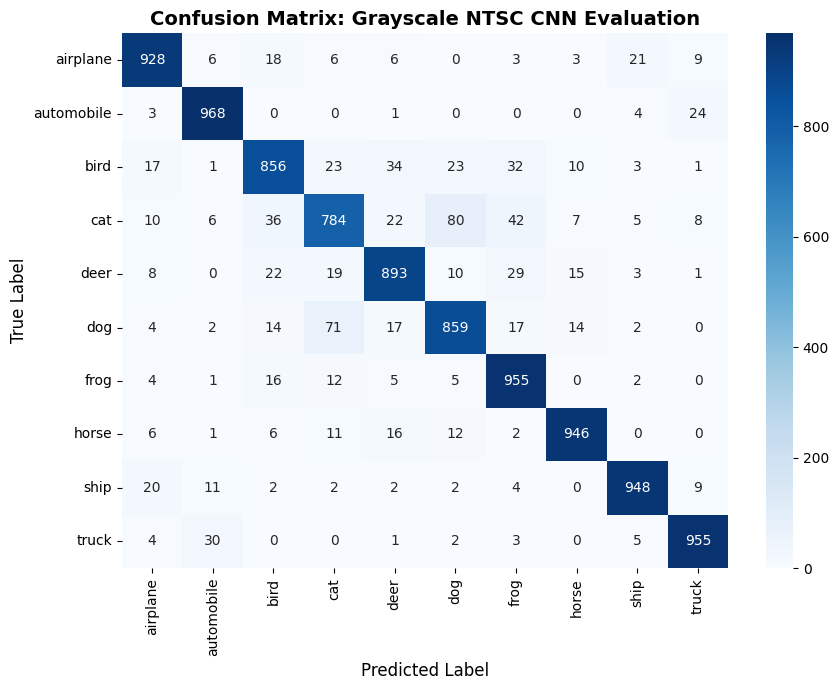

[BERHASIL] Metrik evaluasi CNN NTSC berhasil disimpan dan disinkronkan.


In [3]:
cm_path = os.path.join(ARTIFACT_DIR, 'confusion_matrix_cnn.png')
metrics_cnn = evaluate_classification(
    y_true=y_test,
    y_pred=y_pred_cnn,
    title="Grayscale NTSC CNN Evaluation",
    plot_cm=True,
    save_cm_path=cm_path
)

with open(os.path.join(ARTIFACT_DIR, 'metrics_cnn.json'), 'w') as f:
    json.dump(metrics_cnn, f, indent=2)

# Perbarui juga metrics.json agar selalu sinkron
metrics_json_path = os.path.join(ARTIFACT_DIR, 'metrics.json')
existing_metrics = {}
if os.path.exists(metrics_json_path):
    try:
        with open(metrics_json_path, 'r') as f:
            existing_metrics = json.load(f)
    except Exception:
        pass
existing_metrics['accuracy'] = float(metrics_cnn['accuracy'])
existing_metrics['cnn_test_accuracy'] = float(metrics_cnn['accuracy'])
if 'cnn_eval' in globals():
    existing_metrics['cnn_test_loss'] = float(cnn_eval[0])
with open(metrics_json_path, 'w') as f:
    json.dump(existing_metrics, f, indent=2)
print(f"[BERHASIL] Metrik evaluasi CNN NTSC berhasil disimpan dan disinkronkan.")
